In [1]:
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv


In [2]:
train = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv')
test = pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')
submission = pd.read_csv('/kaggle/input/nlp-getting-started/sample_submission.csv')

In [3]:
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
TRAINING_SIZE=6090

train_shuffle = train.sample(frac=1, random_state=0)


training_sentences = train_shuffle.text[0:TRAINING_SIZE]
training_labels = train_shuffle.target[0:TRAINING_SIZE]

validation_sentences = train_shuffle.text[TRAINING_SIZE:]
validation_labels = train_shuffle.target[TRAINING_SIZE:]

In [5]:
training_sentences.sort_index(ascending=True,inplace=True)
training_labels.sort_index(ascending=True,inplace=True)

validation_sentences.sort_index(ascending=True,inplace=True)
validation_labels.sort_index(ascending=True,inplace=True)

In [6]:
training_labels_final = np.array(training_labels)
validation_labels_final = np.array(validation_labels)

In [7]:
print("{} : {}".format(training_labels[1], training_sentences[1]))
print("{} : {}".format(training_labels[2], training_sentences[2]))
print("{} : {}".format(training_labels[3], training_sentences[3]))

1 : Forest fire near La Ronge Sask. Canada
1 : All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
1 : 13,000 people receive #wildfires evacuation orders in California 


In [8]:
tokenizer = Tokenizer(num_words=100000, oov_token='<OOV>')
tokenizer.fit_on_texts(training_sentences)

tokenizer = Tokenizer(num_words=100000, oov_token='<OOV>')
tokenizer.fit_on_texts(validation_sentences)

In [9]:
training_sequences = tokenizer.texts_to_sequences(training_sentences)
pad_training = pad_sequences(training_sequences, maxlen=25, padding='post', truncating='post')

validation_sequences = tokenizer.texts_to_sequences(validation_sentences)
pad_validation = pad_sequences(validation_sequences, maxlen=25, padding='post', truncating='post')

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(100000, 16, input_length=20),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64,return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

2022-04-14 23:16:05.654045: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


In [11]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [12]:
history = model.fit(pad_training, training_labels_final, epochs=15, validation_data=(pad_validation, validation_labels_final))

2022-04-14 23:16:06.983474: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/15
191/191 [==============================] - 23s 80ms/step - loss: 0.5482 - accuracy: 0.7181 - val_loss: 0.4511 - val_accuracy: 0.7958
Epoch 2/15
191/191 [==============================] - 14s 73ms/step - loss: 0.3795 - accuracy: 0.8417 - val_loss: 0.4485 - val_accuracy: 0.7978
Epoch 3/15
191/191 [==============================] - 13s 70ms/step - loss: 0.3178 - accuracy: 0.8759 - val_loss: 0.4866 - val_accuracy: 0.7919
Epoch 4/15
191/191 [==============================] - 13s 70ms/step - loss: 0.2750 - accuracy: 0.8943 - val_loss: 0.5111 - val_accuracy: 0.7853
Epoch 5/15
191/191 [==============================] - 14s 75ms/step - loss: 0.2476 - accuracy: 0.9089 - val_loss: 0.6148 - val_accuracy: 0.7610
Epoch 6/15
191/191 [==============================] - 13s 70ms/step - loss: 0.2229 - accuracy: 0.9167 - val_loss: 0.6012 - val_accuracy: 0.7682
Epoch 7/15
191/191 [==============================] - 14s 73ms/step - loss: 0.2102 - accuracy: 0.9250 - val_loss: 0.6895 - val_accuracy:

In [13]:
import matplotlib.pyplot as plt
def plot_graph(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.show()

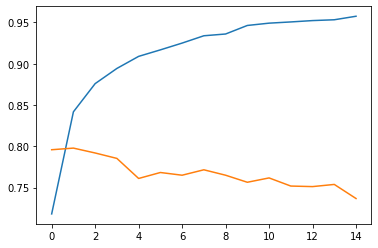

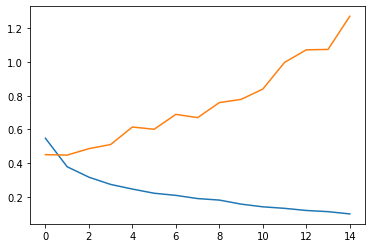

In [14]:
plot_graph(history, 'accuracy')
plot_graph(history, 'loss')

In [15]:
# model_gru = tf.keras.Sequential([
    # tf.keras.layers.Embedding(100000, 16, input_length=20),
    # tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
    # tf.keras.layers.Dense(32, activation='relu'),
    # tf.keras.layers.Dense(1, activation='sigmoid')
# ])
# model_gru.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [16]:
# history = model_gru.fit(pad_training, training_labels_final, epochs=15, validation_data=(pad_validation, validation_labels_final))

In [17]:
# plot_graph(history, 'accuracy')
# plot_graph(history, 'loss')

In [18]:
test_sequences = tokenizer.texts_to_sequences(test.text)
pad_test = pad_sequences(test_sequences,maxlen=25, padding='post', truncating='post')

In [19]:
prediction = model.predict(pad_test)
submission['target'] = (prediction>0.5).astype(int)

In [20]:
submission.to_csv('submission.csv', index=False, header=True)